In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline, griddata
from mpl_toolkits.mplot3d import Axes3D
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

In [2]:
ticker = yf.Ticker("^SPX")
spot = ticker.history(period="5d")["Close"].dropna().iloc[-1]
print("Spot:", spot)
expiries = ticker.options
print("Total Expiries:", len(expiries))
print(expiries[:10])

Spot: 6354.25
Total Expiries: 53
('2026-03-30', '2026-03-31', '2026-04-01', '2026-04-02', '2026-04-06', '2026-04-07', '2026-04-08', '2026-04-09', '2026-04-10', '2026-04-13')


In [3]:
all_options = []

for expiry in expiries:
    try:
        chain = ticker.option_chain(expiry)

        calls = chain.calls.copy()
        puts = chain.puts.copy()

        calls["expiry"] = expiry
        puts["expiry"] = expiry

        calls["type"] = "Call"
        puts["type"] = "Put"

        all_options.append(calls)
        all_options.append(puts)

    except Exception as e:
        print(f"Skipping {expiry} due to error: {e}")

df = pd.concat(all_options, ignore_index=True)
df.head()

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,expiry,type
0,SPXW260330C02800000,2026-03-30 16:59:15+00:00,2800.0,3577.08,3551.7,3568.6,-177.79004,-4.734919,20.0,0.0,6.713381,True,REGULAR,USD,2026-03-30,Call
1,SPXW260330C04200000,2026-03-27 19:58:07+00:00,4200.0,2168.30,2151.7,2169.9,0.00000,0.000000,87.0,13.0,3.674806,True,REGULAR,USD,2026-03-30,Call
2,SPXW260330C04400000,2026-03-26 19:31:06+00:00,4400.0,2087.68,1951.7,1969.9,0.00000,0.000000,NaN,1.0,3.306886,True,REGULAR,USD,2026-03-30,Call
3,SPXW260330C04600000,2026-03-27 19:20:59+00:00,4600.0,1777.23,1751.7,1769.9,0.00000,0.000000,4.0,4.0,2.952517,True,REGULAR,USD,2026-03-30,Call
4,SPXW260330C04800000,2026-03-30 13:53:39+00:00,4800.0,1589.45,1550.2,1569.7,12.00000,0.760721,1.0,21.0,2.545658,True,REGULAR,USD,2026-03-30,Call


In [4]:
today = pd.Timestamp.today().normalize()

df["expiry"] = pd.to_datetime(df["expiry"])
df["T"] = (df["expiry"] - today).dt.days / 365.0  # use calendar basis for options

cols_to_keep = [
    "contractSymbol", "strike", "lastPrice", "bid", "ask", "change", "percentChange",
    "volume", "openInterest", "impliedVolatility", "inTheMoney", "type", "expiry", "T"
]
df = df[[c for c in cols_to_keep if c in df.columns]].copy()


df = df.dropna(subset=["strike", "impliedVolatility", "T"])
df = df[df["T"] > 0]
df = df[df["impliedVolatility"] > 0]
df = df[df["impliedVolatility"] < 3.0]  # remove absurd IV outliers

if "openInterest" in df.columns:
    df = df[df["openInterest"].fillna(0) > 0]

if "volume" in df.columns:
    df = df[df["volume"].fillna(0) >= 0]


df["forward"] = spot
df["log_moneyness"] = np.log(df["strike"] / df["forward"])
df.head()

,contractSymbol,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,type,expiry,T,forward,log_moneyness
1413,SPXW260401C04800000,4800.0,1580.00,1547.8,1568.3,0.0,0.0,1.0,1.0,1.366580,True,Call,2026-04-01,0.00274,6354.25,-0.280508
1414,SPXW260401C05300000,5300.0,1116.87,1050.5,1069.9,0.0,0.0,17.0,17.0,1.016668,True,Call,2026-04-01,0.00274,6354.25,-0.181417
1415,SPXW260401C05400000,5400.0,1020.62,950.0,968.6,0.0,0.0,1.0,1.0,0.897218,True,Call,2026-04-01,0.00274,6354.25,-0.162725
1416,SPXW260401C06000000,6000.0,439.93,352.6,370.2,0.0,0.0,1.0,1.0,0.512883,True,Call,2026-04-01,0.00274,6354.25,-0.057364
1417,SPXW260401C06080000,6080.0,487.47,276.0,289.6,0.0,0.0,NaN,1.0,0.419973,True,Call,2026-04-01,0.00274,6354.25,-0.044119


In [5]:
left_wing = df[(df["strike"] < df["forward"]) & (df["type"] == "Put")].copy()
right_wing = df[(df["strike"] > df["forward"]) & (df["type"] == "Call")].copy()

atm_band = 0.01 
atm_df = df[np.abs(df["strike"] / df["forward"] - 1) <= atm_band].copy()

atm_avg = ( atm_df.groupby(["expiry", "T", "strike", "forward", "log_moneyness"], as_index=False)["impliedVolatility"].mean())
atm_avg["type"] = "ATM"

surface_df = pd.concat([left_wing, right_wing, atm_avg], ignore_index=True)
surface_df = surface_df.sort_values(["expiry", "strike"]).reset_index(drop=True)
surface_df.head()

,contractSymbol,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,type,expiry,T,forward,log_moneyness
0,SPXW260401P02800000,2800.0,0.05,0.0,0.05,0.0,0.0,1.0,41.0,2.453129,False,Put,2026-04-01,0.00274,6354.25,-0.819504
1,SPXW260401P03000000,3000.0,0.05,0.0,0.05,0.0,0.0,10.0,22.0,2.250004,False,Put,2026-04-01,0.00274,6354.25,-0.750512
2,SPXW260401P03200000,3200.0,0.15,0.0,0.05,0.0,0.0,85.0,106.0,2.062505,False,Put,2026-04-01,0.00274,6354.25,-0.685973
3,SPXW260401P03400000,3400.0,0.05,0.0,0.05,0.0,0.0,2.0,207.0,1.890626,False,Put,2026-04-01,0.00274,6354.25,-0.625348
4,SPXW260401P03600000,3600.0,0.10,0.0,0.05,0.0,0.0,22.0,198.0,1.726564,False,Put,2026-04-01,0.00274,6354.25,-0.568190


In [6]:
print("Cleaned OTM/ATM dataset shape:", surface_df.shape)
print(surface_df[["expiry", "type"]].value_counts().head(20))

Cleaned OTM/ATM dataset shape: (11030, 16)
expiry      type
2026-12-31  Call    293
2026-04-30  Call    287
2026-05-29  Call    272
2026-04-17  Put     261
2026-05-15  Put     247
2026-04-17  Call    239
2026-05-15  Call    226
2026-06-18  Put     223
            Call    219
2026-09-30  Call    198
2026-06-30  Call    197
2026-07-17  Put     187
            Call    187
2026-06-30  Put     179
2026-04-30  Put     177
2026-08-21  Put     168
2026-05-29  Put     165
2026-09-18  Put     165
2026-04-02  Call    156
2026-08-21  Call    153
Name: count, dtype: int64


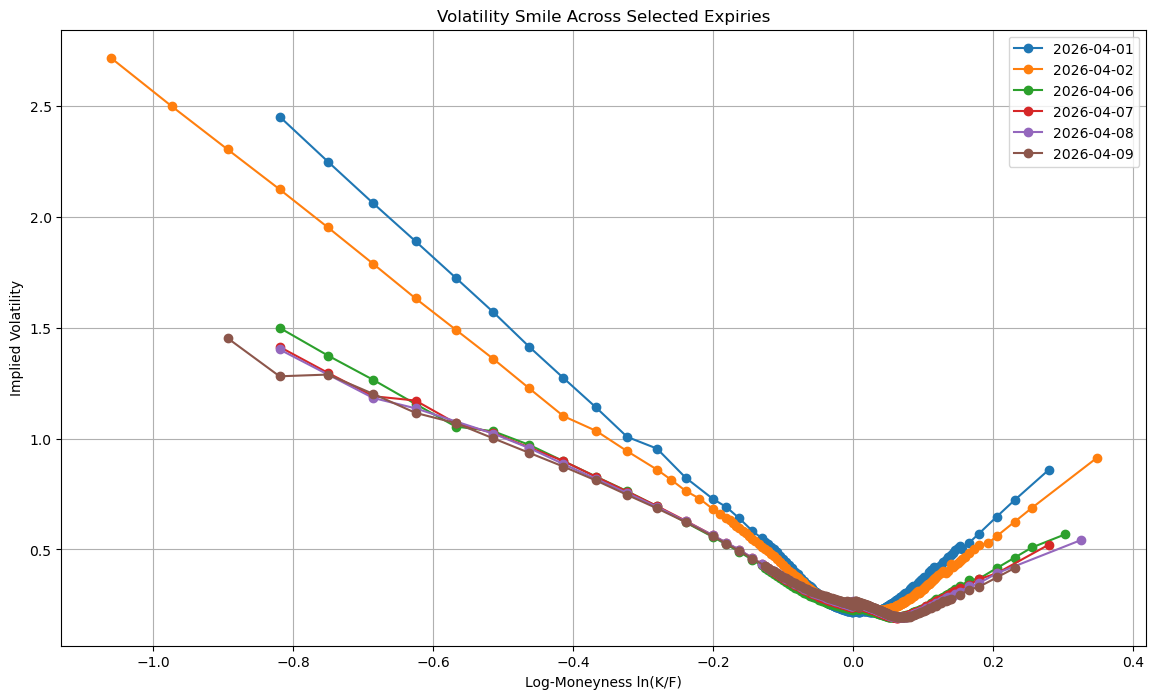

In [7]:
selected_expiries = surface_df["expiry"].drop_duplicates().sort_values().iloc[:6]

plt.figure(figsize=(14, 8))
for exp in selected_expiries:
    temp = surface_df[surface_df["expiry"] == exp].sort_values("log_moneyness")
    plt.plot(temp["log_moneyness"], temp["impliedVolatility"], marker='o', label=str(exp.date()))

plt.xlabel("Log-Moneyness ln(K/F)")
plt.ylabel("Implied Volatility")
plt.title("Volatility Smile Across Selected Expiries")
plt.legend()
plt.show()

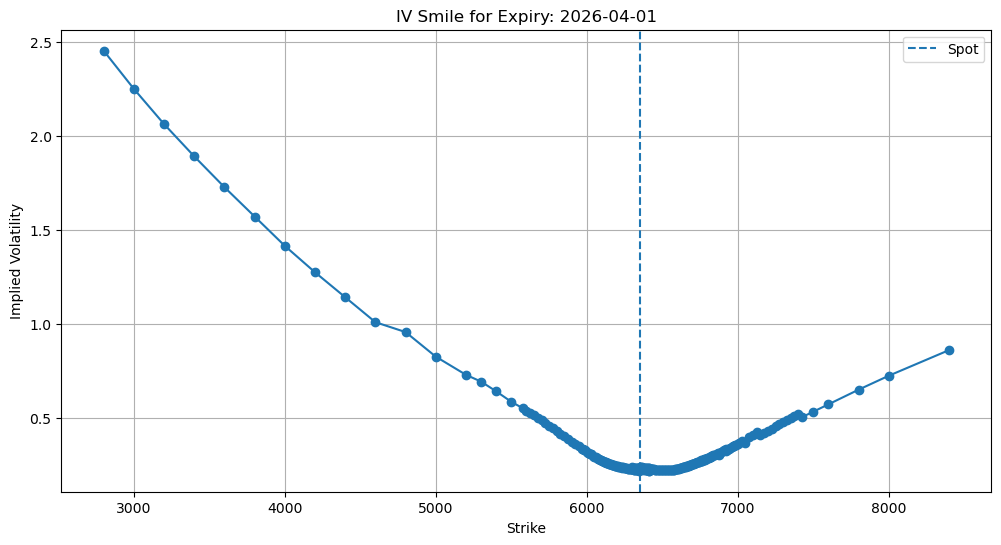

In [8]:
one_expiry = surface_df["expiry"].drop_duplicates().sort_values().iloc[0]
temp = surface_df[surface_df["expiry"] == one_expiry].sort_values("strike")

plt.figure(figsize=(12, 6))
plt.plot(temp["strike"], temp["impliedVolatility"], marker='o')
plt.axvline(spot, linestyle="--", label="Spot")
plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.title(f"IV Smile for Expiry: {one_expiry.date()}")
plt.legend()
plt.show()

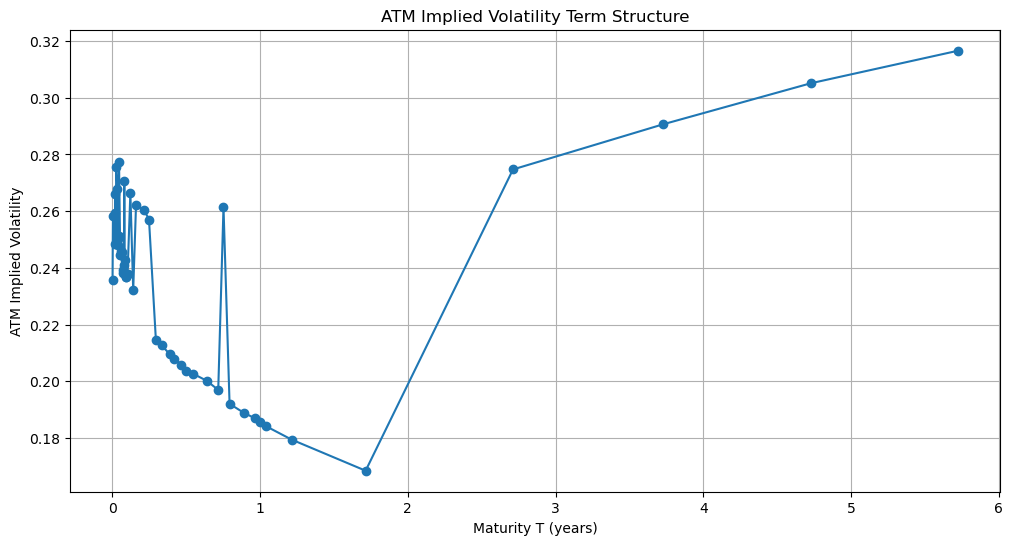

,expiry,contractSymbol,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,type,T,forward,log_moneyness,abs_k
0,2026-04-01,SPXW260401C06355000,6355.0,53.90,54.1,54.3,-31.890000,-37.172165,47.0,13.0,0.235619,True,Call,0.002740,6354.25,0.000118,0.000118
1,2026-04-02,SPXW260402C06355000,6355.0,72.30,68.4,68.7,-21.799995,-23.166840,65.0,31.0,0.258308,True,Call,0.005479,6354.25,0.000118,0.000118
2,2026-04-06,SPXW260406C06355000,6355.0,96.20,93.1,93.4,-16.700005,-14.791855,21.0,8.0,0.248459,True,Call,0.016438,6354.25,0.000118,0.000118
3,2026-04-07,SPXW260407C06355000,6355.0,125.65,103.1,103.4,-9.920006,-7.317257,1.0,2.0,0.259498,True,Call,0.019178,6354.25,0.000118,0.000118
4,2026-04-08,SPXW260408C06355000,6355.0,133.46,111.2,111.7,-11.929993,-8.205511,4.0,1.0,0.265960,True,Call,0.021918,6354.25,0.000118,0.000118


In [10]:
atm_term = (
    surface_df.assign(abs_k=np.abs(surface_df["log_moneyness"]))
    .sort_values(["expiry", "abs_k"])
    .groupby("expiry", as_index=False)
    .first()
)

plt.figure(figsize=(12, 6))
plt.plot(atm_term["T"], atm_term["impliedVolatility"], marker='o')
plt.xlabel("Maturity T (years)")
plt.ylabel("ATM Implied Volatility")
plt.title("ATM Implied Volatility Term Structure")
plt.show()
atm_term.head()

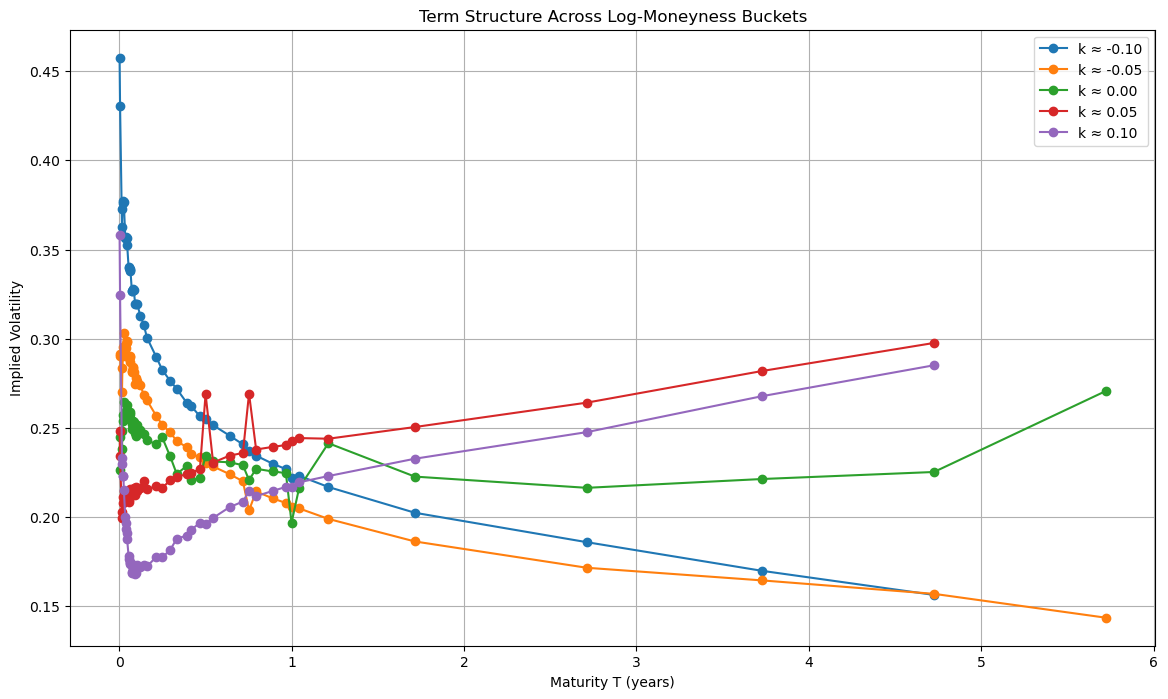

In [14]:
bucket_targets = [-0.10, -0.05, 0.0, 0.05, 0.10]
bucket_tol = 0.015

plt.figure(figsize=(14, 8))

for target in bucket_targets:
    bucket = surface_df[np.abs(surface_df["log_moneyness"] - target) <= bucket_tol].copy()
    if bucket.empty:
        continue

    bucket = (
        bucket.groupby(["expiry", "T"], as_index=False)["impliedVolatility"]
        .mean()
        .sort_values("T")
    )

    plt.plot(bucket["T"], bucket["impliedVolatility"], marker='o', label=f"k ≈ {target:.2f}")

plt.xlabel("Maturity T (years)")
plt.ylabel("Implied Volatility")
plt.title("Term Structure Across Log-Moneyness Buckets")
plt.legend()
plt.show()

In [15]:
smile_spline_data = []

unique_expiries = surface_df["expiry"].drop_duplicates().sort_values()

for exp in unique_expiries:
    temp = surface_df[surface_df["expiry"] == exp].sort_values("log_moneyness").copy()
    temp = temp.groupby("log_moneyness", as_index=False)["impliedVolatility"].mean()

    if len(temp) < 4:
        continue

    x = temp["log_moneyness"].values
    y = temp["impliedVolatility"].values

    try:
        spline = CubicSpline(x, y, bc_type="natural")
        x_smooth = np.linspace(x.min(), x.max(), 200)
        y_smooth = spline(x_smooth)

        temp_spline = pd.DataFrame({
            "expiry": exp,
            "T": (exp - today).days / 365.0,
            "log_moneyness": x_smooth,
            "impliedVolatility": y_smooth
        })

        smile_spline_data.append(temp_spline)

    except Exception as e:
        print(f"Spline failed for {exp.date()}: {e}")

smile_spline_df = pd.concat(smile_spline_data, ignore_index=True)
smile_spline_df.head()

,expiry,T,log_moneyness,impliedVolatility
0,2026-04-01,0.00274,-0.819504,2.453129
1,2026-04-01,0.00274,-0.813984,2.436851
2,2026-04-01,0.00274,-0.808463,2.420573
3,2026-04-01,0.00274,-0.802942,2.404298
4,2026-04-01,0.00274,-0.797422,2.388026


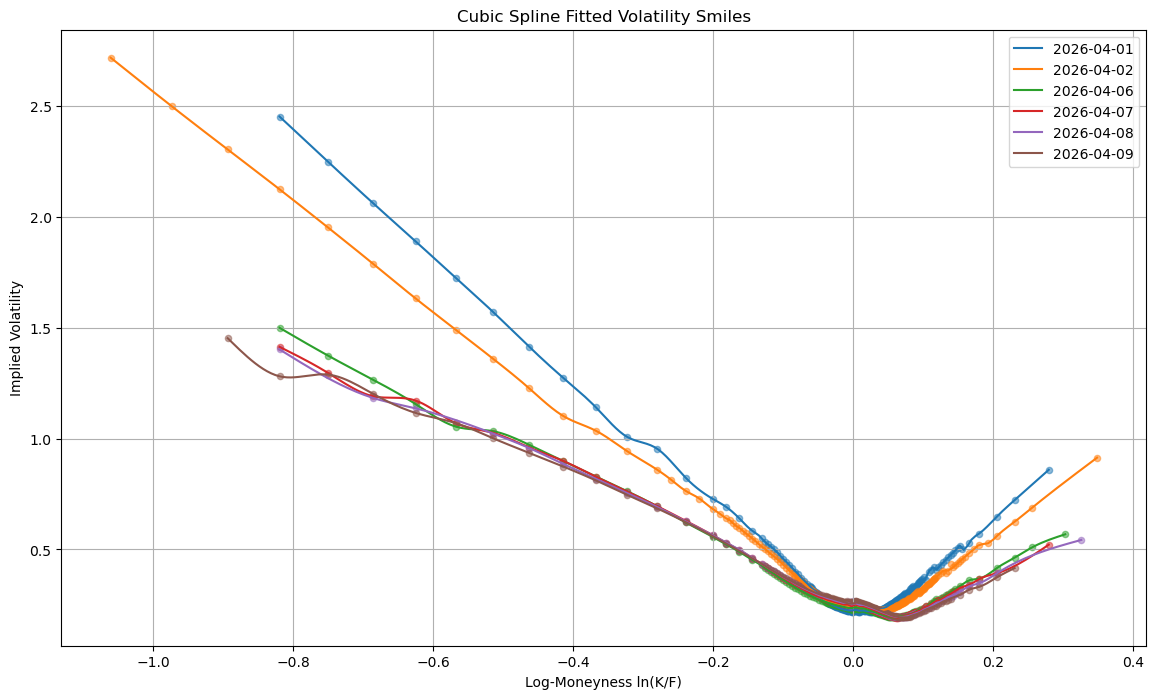

In [16]:
selected_expiries = smile_spline_df["expiry"].drop_duplicates().sort_values().iloc[:6]

plt.figure(figsize=(14, 8))

for exp in selected_expiries:
    raw = surface_df[surface_df["expiry"] == exp].sort_values("log_moneyness")
    smooth = smile_spline_df[smile_spline_df["expiry"] == exp].sort_values("log_moneyness")

    plt.scatter(raw["log_moneyness"], raw["impliedVolatility"], s=20, alpha=0.5)
    plt.plot(smooth["log_moneyness"], smooth["impliedVolatility"], label=str(exp.date()))

plt.xlabel("Log-Moneyness ln(K/F)")
plt.ylabel("Implied Volatility")
plt.title("Cubic Spline Fitted Volatility Smiles")
plt.legend()
plt.show()

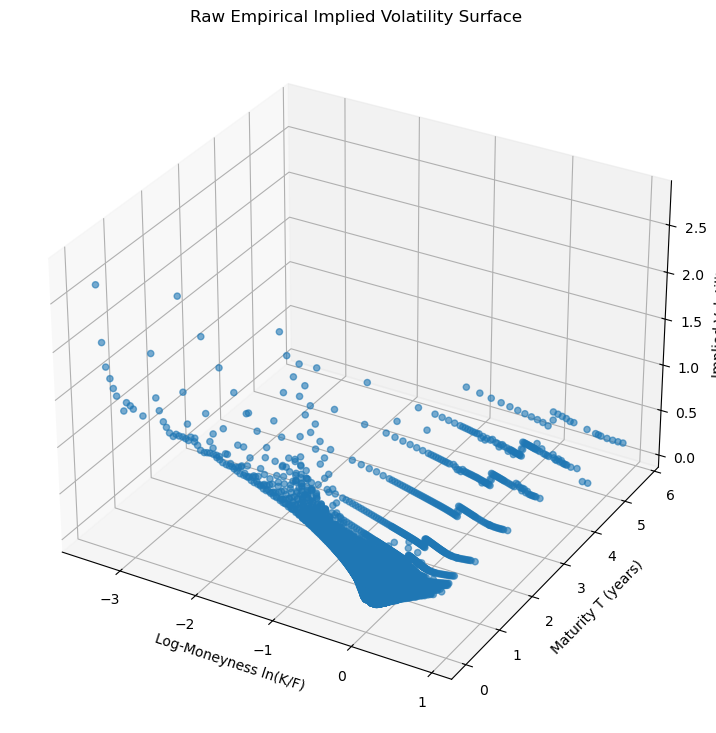

In [17]:
fig = plt.figure(figsize=(16, 9))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    surface_df["log_moneyness"],
    surface_df["T"],
    surface_df["impliedVolatility"],
    alpha=0.6
)

ax.set_xlabel("Log-Moneyness ln(K/F)")
ax.set_ylabel("Maturity T (years)")
ax.set_zlabel("Implied Volatility")
ax.set_title("Raw Empirical Implied Volatility Surface")
plt.show()

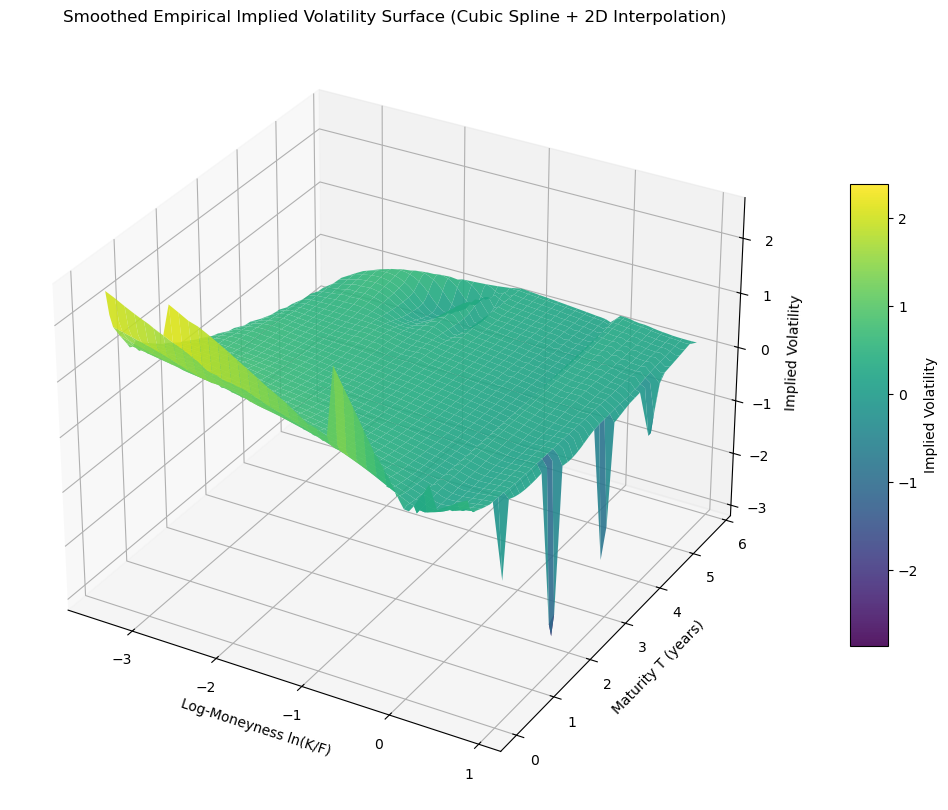

In [19]:
points = smile_spline_df[["log_moneyness", "T"]].values
values = smile_spline_df["impliedVolatility"].values

k_grid = np.linspace(smile_spline_df["log_moneyness"].min(),
                     smile_spline_df["log_moneyness"].max(), 80)

T_grid = np.linspace(smile_spline_df["T"].min(),
                     smile_spline_df["T"].max(), 80)

K_mesh, T_mesh = np.meshgrid(k_grid, T_grid)

IV_grid = griddata(points, values, (K_mesh, T_mesh), method="cubic")

# Optional fallback for missing areas
IV_grid_linear = griddata(points, values, (K_mesh, T_mesh), method="linear")
IV_grid = np.where(np.isnan(IV_grid), IV_grid_linear, IV_grid)
fig = plt.figure(figsize=(18, 10))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(K_mesh, T_mesh, IV_grid, cmap="viridis", edgecolor="none", alpha=0.9)

ax.set_xlabel("Log-Moneyness ln(K/F)")
ax.set_ylabel("Maturity T (years)")
ax.set_zlabel("Implied Volatility")
ax.set_title("Smoothed Empirical Implied Volatility Surface (Cubic Spline + 2D Interpolation)")

fig.colorbar(surf, shrink=0.6, aspect=12, label="Implied Volatility")
plt.show()

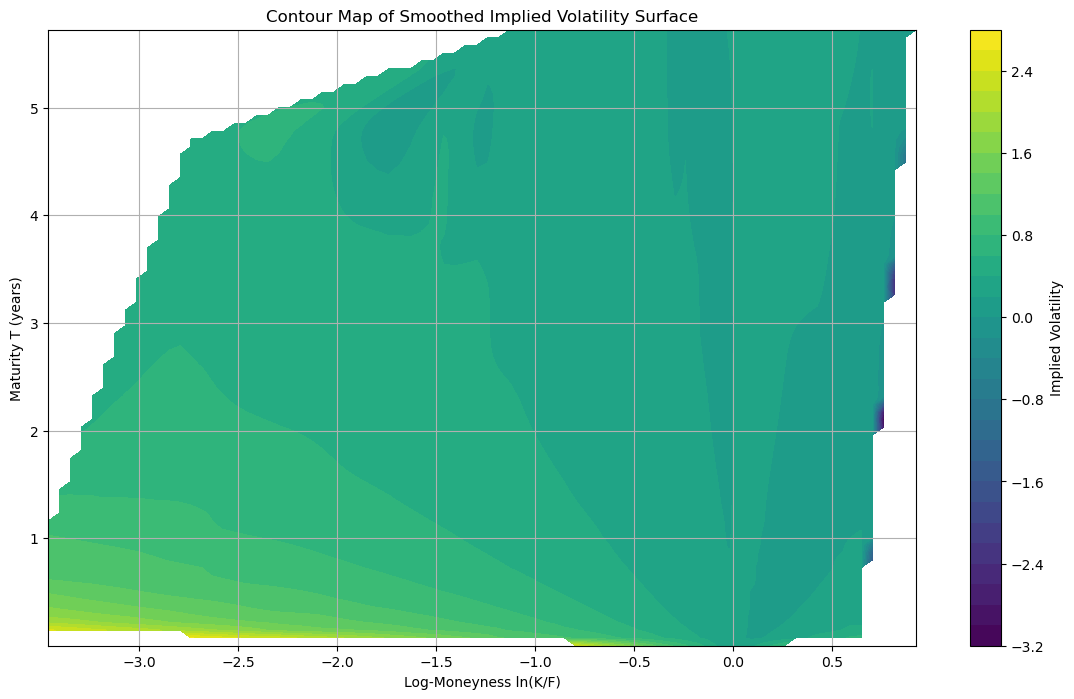

In [20]:
plt.figure(figsize=(14, 8))
contour = plt.contourf(K_mesh, T_mesh, IV_grid, levels=30, cmap="viridis")
plt.colorbar(contour, label="Implied Volatility")
plt.xlabel("Log-Moneyness ln(K/F)")
plt.ylabel("Maturity T (years)")
plt.title("Contour Map of Smoothed Implied Volatility Surface")
plt.show()